# SAM2 Interactive Annotation v2

- 交互式选择 `serial_id` 和 `frame_idx`
- 每次提交掩码时手动指定物体像素值编号
- 显式 `Load / Preview / Commit / Undo / Load saved / Save` 工作流，减少误操作
- 更清晰的状态展示：左侧是叠加结果，右侧是当前 composite mask
- 如果 notebook 后端支持 live canvas，可以直接在图上点前景/背景点
- 如果后端不支持 live canvas，也会显示静态图片预览，并且可以用 `X / Y / Add Point` 手动加点



In [5]:
import io
import re
from importlib.util import find_spec
from pathlib import Path

import cv2
import ipywidgets as widgets
import matplotlib
import numpy as np
import torch
import yaml
from IPython import get_ipython
from IPython.display import clear_output, display
from PIL import Image

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor


def setup_matplotlib_backend():
    ip = get_ipython()
    if ip is None:
        matplotlib.use("Agg", force=True)
        return "Agg"

    backend_attempts = []
    if find_spec("ipympl") is not None:
        backend_attempts.append(("widget", "ipympl"))
    backend_attempts.extend([
        ("notebook", "nbAgg"),
        ("inline", "inline"),
    ])

    errors = []
    for magic_name, backend_name in backend_attempts:
        try:
            ip.run_line_magic("matplotlib", magic_name)
            return backend_name
        except Exception as exc:
            errors.append(f"{magic_name}: {exc}")

    matplotlib.use("Agg", force=True)
    print("Matplotlib backend fallback log:")
    for err in errors:
        print(f"  - {err}")
    return "Agg"


MATPLOTLIB_BACKEND = setup_matplotlib_backend()
LIVE_CANVAS_BACKENDS = {"ipympl", "nbagg", "widget"}
LIVE_CANVAS_SUPPORTED = str(MATPLOTLIB_BACKEND).lower() in LIVE_CANVAS_BACKENDS

import matplotlib.pyplot as plt

print(f"Using matplotlib backend: {MATPLOTLIB_BACKEND}")
print(f"Live canvas supported: {LIVE_CANVAS_SUPPORTED}")


def choose_device():
    if torch.cuda.is_available():
        device = "cuda:1"
        try:
            if torch.cuda.get_device_properties(0).major >= 8:
                torch.backends.cuda.matmul.allow_tf32 = True
                torch.backends.cudnn.allow_tf32 = True
                print("TF32 enabled for CUDA")
        except Exception as exc:
            print(f"Could not enable TF32: {exc}")
    else:
        device = "cpu"
    return device


DEVICE = choose_device()
print(f"Using device: {DEVICE}")

COLOR_PALETTE = [
    np.array([0.11, 0.62, 0.47, 0.60]),
    np.array([0.85, 0.37, 0.01, 0.60]),
    np.array([0.46, 0.44, 0.70, 0.60]),
    np.array([0.91, 0.16, 0.54, 0.60]),
    np.array([0.40, 0.65, 0.12, 0.60]),
    np.array([0.90, 0.67, 0.01, 0.60]),
    np.array([0.65, 0.46, 0.11, 0.60]),
    np.array([0.40, 0.40, 0.40, 0.60]),
]
PREVIEW_COLOR = np.array([1.0, 1.0, 1.0, 0.45])
POINT_SIZE = 170
MAX_LABEL_VALUE = 255


def show_mask(mask, ax, color, borders=True):
    mask_uint8 = mask.astype(np.uint8)
    h, w = mask_uint8.shape[-2:]
    mask_rgba = mask_uint8.reshape(h, w, 1) * color.reshape(1, 1, 4)
    ax.imshow(mask_rgba)

    if borders:
        contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        if contours:
            border_canvas = np.zeros((h, w, 4), dtype=np.float32)
            cv2.drawContours(border_canvas, contours, -1, (1.0, 1.0, 1.0, 0.95), thickness=2)
            ax.imshow(border_canvas)


def show_points(coords, labels, ax, marker_size=POINT_SIZE):
    coords = np.asarray(coords)
    labels = np.asarray(labels)
    if coords.size == 0:
        return

    pos_points = coords[labels == 1]
    neg_points = coords[labels == 0]

    if len(pos_points):
        ax.scatter(
            pos_points[:, 0],
            pos_points[:, 1],
            color="lime",
            marker="*",
            s=marker_size,
            edgecolor="white",
            linewidth=1.2,
        )
    if len(neg_points):
        ax.scatter(
            neg_points[:, 0],
            neg_points[:, 1],
            color="red",
            marker="*",
            s=marker_size,
            edgecolor="white",
            linewidth=1.2,
        )


def draw_label_text(mask, label, ax):
    ys, xs = np.nonzero(mask)
    if len(xs) == 0:
        return
    x = float(xs.mean())
    y = float(ys.mean())
    ax.text(
        x,
        y,
        str(label),
        color="white",
        fontsize=12,
        fontweight="bold",
        ha="center",
        va="center",
        bbox={"facecolor": "black", "alpha": 0.55, "pad": 2, "edgecolor": "none"},
    )


def format_label_list(labels):
    return "none" if not labels else ", ".join(str(x) for x in labels)


print("Imports and helpers ready.")


Using matplotlib backend: ipympl
Live canvas supported: True
TF32 enabled for CUDA
Using device: cuda:1
Imports and helpers ready.


In [6]:
SEQUENCE_DIR = Path("datasets/subject_5/20231027_112303")
SAM2_CHECKPOINT = Path("config/checkpoints/sam2/sam2.1_hiera_large.pt")
SAM2_MODEL_CFG = "configs/sam2.1/sam2.1_hiera_l.yaml"
OUTPUT_SUBDIR = Path("processed/segmentation/init")

try:
    sam2_model = build_sam2(SAM2_MODEL_CFG, str(SAM2_CHECKPOINT), device=DEVICE)
    predictor = SAM2ImagePredictor(sam2_model)
    print("SAM2 model loaded successfully.")
except Exception as exc:
    predictor = None
    print(f"Failed to load SAM2 model: {exc}")


SAM2 model loaded successfully.


In [7]:
class InteractiveSAM2Annotator:
    def __init__(self, predictor, sequence_dir, output_subdir=OUTPUT_SUBDIR):
        self.predictor = predictor
        self.sequence_dir = Path(sequence_dir)
        self.output_subdir = Path(output_subdir)
        self.live_canvas_supported = LIVE_CANVAS_SUPPORTED

        self.meta = {}
        self.available_serials = []
        self.available_frames = []
        self.available_frame_set = set()

        self.current_image_path = None
        self.current_image_np = None
        self.current_serial = None
        self.current_frame_idx = None

        self.input_points = []
        self.input_labels = []
        self.preview_mask = None
        self.preview_score = None

        self.committed_masks = []
        self.composite_mask = None
        self.history = []

        self.fig, (self.ax_overlay, self.ax_mask) = plt.subplots(1, 2, figsize=(14, 7))
        if hasattr(self.fig.canvas, "header_visible"):
            self.fig.canvas.header_visible = False
        if hasattr(self.fig.canvas, "footer_visible"):
            self.fig.canvas.footer_visible = False
        if hasattr(self.fig.canvas, "toolbar_visible"):
            self.fig.canvas.toolbar_visible = True
        self.fig.tight_layout()
        self.fig.canvas.mpl_connect("button_press_event", self.on_canvas_click)

        self.figure_output = widgets.Output(layout=widgets.Layout(border="1px solid #bbb", width="100%"))
        self.figure_image = widgets.Image(format="png", layout=widgets.Layout(width="100%"))
        self.figure_mode_html = widgets.HTML()

        self.sequence_text = widgets.Text(
            value=str(self.sequence_dir),
            description="Sequence",
            layout=widgets.Layout(width="560px"),
            style={"description_width": "initial"},
        )
        self.refresh_button = widgets.Button(description="Refresh", button_style="info")

        self.serial_dropdown = widgets.Dropdown(
            description="Serial",
            options=[],
            style={"description_width": "initial"},
            layout=widgets.Layout(width="240px"),
        )
        self.frame_slider = widgets.IntSlider(
            description="Frame",
            min=0,
            max=0,
            value=0,
            step=1,
            continuous_update=False,
            readout=False,
            style={"description_width": "initial"},
            layout=widgets.Layout(width="360px"),
        )
        self.frame_text = widgets.BoundedIntText(
            description="Frame idx",
            min=0,
            max=0,
            value=0,
            step=1,
            style={"description_width": "initial"},
            layout=widgets.Layout(width="180px"),
        )
        widgets.jslink((self.frame_slider, "value"), (self.frame_text, "value"))

        self.load_button = widgets.Button(description="Load Frame", button_style="primary")
        self.auto_load_saved_checkbox = widgets.Checkbox(
            value=False,
            description="Auto load saved mask when frame loads",
            indent=False,
        )

        self.click_mode = widgets.RadioButtons(
            options=[("Foreground (+)", 1), ("Background (-)", 0)],
            value=1,
            description="Click mode",
            style={"description_width": "initial"},
        )
        self.point_x_input = widgets.BoundedIntText(
            value=0,
            min=0,
            max=0,
            step=1,
            description="X",
            style={"description_width": "initial"},
            layout=widgets.Layout(width="140px"),
        )
        self.point_y_input = widgets.BoundedIntText(
            value=0,
            min=0,
            max=0,
            step=1,
            description="Y",
            style={"description_width": "initial"},
            layout=widgets.Layout(width="140px"),
        )
        self.add_point_button = widgets.Button(description="Add Point", button_style="info")
        self.remove_last_point_button = widgets.Button(description="Remove Last Point")

        self.pixel_value_input = widgets.BoundedIntText(
            value=1,
            min=1,
            max=MAX_LABEL_VALUE,
            step=1,
            description="Pixel value",
            style={"description_width": "initial"},
            layout=widgets.Layout(width="170px"),
        )
        self.overwrite_same_label_checkbox = widgets.Checkbox(
            value=False,
            description="Overwrite same value",
            indent=False,
        )
        self.overlap_mode = widgets.Dropdown(
            options=[
                ("Replace overlapping labels", "replace"),
                ("Keep existing labels", "keep"),
            ],
            value="replace",
            description="Overlap",
            style={"description_width": "initial"},
            layout=widgets.Layout(width="280px"),
        )

        self.preview_button = widgets.Button(description="Preview Mask", button_style="info")
        self.commit_button = widgets.Button(description="Commit Mask", button_style="success")
        self.undo_button = widgets.Button(description="Undo Last")
        self.clear_points_button = widgets.Button(description="Clear Points")
        self.clear_preview_button = widgets.Button(description="Drop Preview")
        self.reset_masks_button = widgets.Button(description="Reset Masks", button_style="warning")
        self.load_saved_button = widgets.Button(description="Load Saved Mask")
        self.save_button = widgets.Button(description="Save Mask", button_style="success")

        self.path_html = widgets.HTML()
        self.status_output = widgets.Output(layout={"border": "1px solid #bbb", "height": "160px", "overflow_y": "auto"})

        self.refresh_button.on_click(self.on_refresh_clicked)
        self.serial_dropdown.observe(self.on_serial_changed, names="value")
        self.frame_slider.observe(self.on_frame_changed, names="value")
        self.load_button.on_click(self.on_load_clicked)
        self.add_point_button.on_click(self.on_add_point_clicked)
        self.remove_last_point_button.on_click(self.on_remove_last_point_clicked)
        self.preview_button.on_click(self.on_preview_clicked)
        self.commit_button.on_click(self.on_commit_clicked)
        self.undo_button.on_click(self.on_undo_clicked)
        self.clear_points_button.on_click(self.on_clear_points_clicked)
        self.clear_preview_button.on_click(self.on_clear_preview_clicked)
        self.reset_masks_button.on_click(self.on_reset_masks_clicked)
        self.load_saved_button.on_click(self.on_load_saved_clicked)
        self.save_button.on_click(self.on_save_clicked)

        self._displayed_controls = None
        self.refresh_sequence_state(preserve_selection=False)
        self.refresh_figure_panel(force=True)
        self.update_display()

    def display(self):
        figure_widget = self.fig.canvas if self.live_canvas_supported else self.figure_output
        controls = widgets.VBox([
            widgets.HBox([self.sequence_text, self.refresh_button]),
            widgets.HBox([self.serial_dropdown, self.frame_slider, self.frame_text, self.load_button]),
            self.auto_load_saved_checkbox,
            self.figure_mode_html,
            widgets.HBox([self.click_mode, self.point_x_input, self.point_y_input, self.add_point_button, self.remove_last_point_button]),
            widgets.HBox([self.pixel_value_input, self.overwrite_same_label_checkbox, self.overlap_mode]),
            widgets.HBox([
                self.preview_button,
                self.commit_button,
                self.undo_button,
                self.clear_points_button,
                self.clear_preview_button,
                self.reset_masks_button,
            ]),
            widgets.HBox([self.load_saved_button, self.save_button]),
            self.path_html,
            self.status_output,
            figure_widget,
        ])
        self._displayed_controls = controls
        display(controls)
        self.refresh_figure_panel(force=True)

    def close(self):
        if self._displayed_controls is not None:
            try:
                self._displayed_controls.close()
            except Exception:
                pass
        try:
            plt.close(self.fig)
        except Exception:
            pass

    def log(self, *lines, clear=False):
        with self.status_output:
            if clear:
                clear_output(wait=True)
            for line in lines:
                print(line)

    def read_meta(self):
        meta_path = self.sequence_dir / "meta.yaml"
        if not meta_path.exists():
            return {}
        with meta_path.open("r", encoding="utf-8") as f:
            return yaml.safe_load(f) or {}

    def discover_serials(self):
        serial_dirs = []
        if not self.sequence_dir.exists():
            return serial_dirs
        for child in sorted(self.sequence_dir.iterdir()):
            if not child.is_dir():
                continue
            if re.fullmatch(r"\d+", child.name) and any(child.glob("color_*.jpg")):
                serial_dirs.append(child.name)
        return serial_dirs

    def discover_frames(self, serial):
        serial_dir = self.sequence_dir / str(serial)
        frames = []
        for path in sorted(serial_dir.glob("color_*.jpg")):
            try:
                frames.append(int(path.stem.split("_")[-1]))
            except ValueError:
                continue
        return frames

    def update_backend_message(self):
        if self.live_canvas_supported:
            msg = (
                f"<b>Canvas mode:</b> live ({MATPLOTLIB_BACKEND}). "
                "Figure below is clickable. You can click directly on the image, or use X/Y inputs if you prefer."
            )
        else:
            msg = (
                f"<b>Canvas mode:</b> static ({MATPLOTLIB_BACKEND}). "
                "Current backend does not provide a clickable canvas here, so use X / Y / Add Point."
            )
        self.figure_mode_html.value = msg

    def refresh_figure_panel(self, force=False):
        self.update_backend_message()
        with self.figure_output:
            if force:
                clear_output(wait=True)
                if not self.live_canvas_supported:
                    display(self.figure_image)

    def render_figure_to_png(self):
        buffer = io.BytesIO()
        self.fig.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
        buffer.seek(0)
        self.figure_image.value = buffer.getvalue()

    def update_path_summary(self):
        serial = self.serial_dropdown.value
        frame_idx = int(self.frame_slider.value)
        image_path = self.get_image_path(serial, frame_idx) if serial is not None else None
        save_path = self.get_save_path(serial, frame_idx) if serial is not None else None
        image_status = "exists" if image_path and image_path.exists() else "missing"
        save_status = "exists" if save_path and save_path.exists() else "not saved"
        self.path_html.value = (
            f"<b>Image:</b> {image_path} ({image_status})<br>"
            f"<b>Save path:</b> {save_path} ({save_status})<br>"
            f"<b>Used labels:</b> {format_label_list(self.get_used_labels())}"
        )

    def refresh_sequence_state(self, preserve_selection=True):
        previous_serial = self.serial_dropdown.value if preserve_selection else None
        previous_frame = int(self.frame_slider.value) if preserve_selection else None

        self.sequence_dir = Path(self.sequence_text.value).expanduser()
        self.meta = self.read_meta()
        self.available_serials = self.discover_serials()
        self.serial_dropdown.options = self.available_serials

        if not self.available_serials:
            self.serial_dropdown.value = None
            self.available_frames = []
            self.available_frame_set = set()
            self.frame_slider.min = 0
            self.frame_slider.max = 0
            self.frame_slider.value = 0
            self.frame_text.min = 0
            self.frame_text.max = 0
            self.frame_text.value = 0
            self.sync_point_input_bounds()
            self.update_path_summary()
            self.log(f"No valid serial folders found under {self.sequence_dir}", clear=True)
            return

        default_serial = None
        meta_serials = self.meta.get("realsense", {}).get("serials", [])
        for serial in meta_serials:
            if serial in self.available_serials:
                default_serial = serial
                break
        selected_serial = previous_serial if previous_serial in self.available_serials else (default_serial or self.available_serials[0])
        self.serial_dropdown.value = selected_serial
        self.refresh_frame_range(selected_serial, preferred_frame=previous_frame)
        self.log(
            f"Sequence ready: {self.sequence_dir}",
            f"Serials: {', '.join(self.available_serials)}",
            clear=True,
        )

    def refresh_frame_range(self, serial, preferred_frame=None):
        self.available_frames = self.discover_frames(serial)
        self.available_frame_set = set(self.available_frames)
        if not self.available_frames:
            self.frame_slider.min = 0
            self.frame_slider.max = 0
            self.frame_slider.value = 0
            self.frame_text.min = 0
            self.frame_text.max = 0
            self.frame_text.value = 0
            self.sync_point_input_bounds()
            self.update_path_summary()
            return

        frame_min = int(self.available_frames[0])
        frame_max = int(self.available_frames[-1])
        selected_frame = preferred_frame if preferred_frame in self.available_frame_set else frame_min

        self.frame_slider.min = frame_min
        self.frame_slider.max = frame_max
        self.frame_text.min = frame_min
        self.frame_text.max = frame_max
        self.frame_slider.value = int(selected_frame)
        self.frame_text.value = int(selected_frame)
        self.sync_point_input_bounds()
        self.update_path_summary()

    def sync_point_input_bounds(self):
        if self.current_image_np is None:
            max_x = 0
            max_y = 0
        else:
            h, w = self.current_image_np.shape[:2]
            max_x = max(0, w - 1)
            max_y = max(0, h - 1)

        self.point_x_input.max = max_x
        self.point_y_input.max = max_y
        self.point_x_input.value = int(min(self.point_x_input.value, max_x))
        self.point_y_input.value = int(min(self.point_y_input.value, max_y))

    def get_image_path(self, serial, frame_idx):
        return self.sequence_dir / str(serial) / f"color_{int(frame_idx):06d}.jpg"

    def get_save_path(self, serial, frame_idx):
        return self.sequence_dir / self.output_subdir / str(serial) / f"mask_{int(frame_idx):06d}.png"

    def get_used_labels(self):
        labels = sorted(item["label"] for item in self.committed_masks if item["mask"].any())
        return labels

    def next_free_label(self):
        used = set(self.get_used_labels())
        for label in range(1, MAX_LABEL_VALUE + 1):
            if label not in used:
                return label
        return MAX_LABEL_VALUE

    def color_for_label(self, label):
        return COLOR_PALETTE[(int(label) - 1) % len(COLOR_PALETTE)].copy()

    def clear_interaction(self):
        self.input_points = []
        self.input_labels = []
        self.preview_mask = None
        self.preview_score = None

    def snapshot_mask_state(self):
        return {
            "committed_masks": [
                {
                    "label": item["label"],
                    "mask": item["mask"].copy(),
                    "color": item["color"].copy(),
                }
                for item in self.committed_masks
            ],
            "composite_mask": None if self.composite_mask is None else self.composite_mask.copy(),
        }

    def restore_mask_state(self, snapshot):
        self.committed_masks = [
            {
                "label": item["label"],
                "mask": item["mask"].copy(),
                "color": item["color"].copy(),
            }
            for item in snapshot["committed_masks"]
        ]
        self.composite_mask = None if snapshot["composite_mask"] is None else snapshot["composite_mask"].copy()
        self.pixel_value_input.value = self.next_free_label()

    def push_history(self, note):
        self.history.append((note, self.snapshot_mask_state()))

    def initialize_empty_mask(self):
        if self.current_image_np is None:
            self.composite_mask = None
            self.committed_masks = []
            return
        h, w = self.current_image_np.shape[:2]
        self.composite_mask = np.zeros((h, w), dtype=np.uint8)
        self.committed_masks = []

    def load_frame(self, auto_load_saved=False):
        if self.predictor is None:
            self.log("Predictor is not available. Please check the model loading cell.", clear=True)
            return

        serial = self.serial_dropdown.value
        frame_idx = int(self.frame_slider.value)
        image_path = self.get_image_path(serial, frame_idx)
        if not image_path.exists():
            self.log(f"Image does not exist: {image_path}", clear=True)
            return

        image = Image.open(image_path).convert("RGB")
        self.current_image_np = np.array(image)
        self.current_image_path = image_path
        self.current_serial = str(serial)
        self.current_frame_idx = frame_idx

        self.predictor.set_image(self.current_image_np)
        self.clear_interaction()
        self.initialize_empty_mask()
        self.history = []
        self.sync_point_input_bounds()

        if auto_load_saved:
            self.import_saved_mask(log_when_missing=False)

        self.pixel_value_input.value = self.next_free_label()
        self.update_path_summary()
        self.update_display()
        self.log(
            f"Loaded serial {self.current_serial}, frame {self.current_frame_idx:06d}",
            f"Image: {self.current_image_path}",
            clear=True,
        )

    def import_saved_mask(self, log_when_missing=True):
        if self.current_image_np is None:
            self.log("Load a frame before importing a saved mask.", clear=True)
            return False

        save_path = self.get_save_path(self.current_serial, self.current_frame_idx)
        if not save_path.exists():
            if log_when_missing:
                self.log(f"No saved mask found at {save_path}", clear=True)
            return False

        loaded = cv2.imread(str(save_path), cv2.IMREAD_UNCHANGED)
        if loaded is None:
            self.log(f"Failed to read saved mask: {save_path}", clear=True)
            return False
        if loaded.ndim == 3:
            loaded = loaded[..., 0]
        loaded = loaded.astype(np.uint8)

        expected_shape = self.current_image_np.shape[:2]
        if loaded.shape != expected_shape:
            self.log(
                f"Saved mask shape mismatch: got {loaded.shape}, expected {expected_shape}",
                clear=True,
            )
            return False

        self.push_history("load_saved_mask")
        self.composite_mask = loaded.copy()
        self.committed_masks = []
        for label in sorted(int(v) for v in np.unique(loaded) if v > 0):
            mask = loaded == label
            if mask.any():
                self.committed_masks.append({
                    "label": label,
                    "mask": mask,
                    "color": self.color_for_label(label),
                })

        self.clear_interaction()
        self.pixel_value_input.value = self.next_free_label()
        self.update_path_summary()
        self.update_display()
        self.log(
            f"Loaded saved mask from {save_path}",
            f"Labels: {format_label_list(self.get_used_labels())}",
            clear=True,
        )
        return True

    def add_point(self, x, y):
        if self.current_image_np is None:
            self.log("Load a frame before adding points.", clear=True)
            return False

        h, w = self.current_image_np.shape[:2]
        x = int(np.clip(int(x), 0, w - 1))
        y = int(np.clip(int(y), 0, h - 1))
        self.input_points.append([x, y])
        self.input_labels.append(int(self.click_mode.value))
        self.preview_mask = None
        self.preview_score = None
        self.point_x_input.value = x
        self.point_y_input.value = y
        self.update_display()
        mode_name = "FG" if self.click_mode.value == 1 else "BG"
        self.log(f"Added {mode_name} point at ({x}, {y})", clear=True)
        return True

    def run_preview(self):
        if self.current_image_np is None:
            self.log("Load a frame first.", clear=True)
            return False
        if not self.input_points:
            self.log("Add at least one click before previewing.", clear=True)
            return False

        point_coords = np.asarray(self.input_points, dtype=np.float32)
        point_labels = np.asarray(self.input_labels, dtype=np.int32)
        masks, scores, _ = self.predictor.predict(
            point_coords=point_coords,
            point_labels=point_labels,
            multimask_output=True,
        )
        if masks is None or len(masks) == 0:
            self.preview_mask = None
            self.preview_score = None
            self.update_display()
            self.log("SAM2 did not return any mask.", clear=True)
            return False

        best_idx = int(np.argmax(scores))
        self.preview_mask = masks[best_idx].astype(bool)
        self.preview_score = float(scores[best_idx])
        score_text = ", ".join(f"{float(s):.4f}" for s in scores)
        self.update_display()
        self.log(
            f"Preview ready. Best score: {self.preview_score:.4f}",
            f"All candidate scores: [{score_text}]",
            clear=True,
        )
        return True

    def remove_label(self, label):
        label = int(label)
        if self.composite_mask is not None:
            self.composite_mask[self.composite_mask == label] = 0
        self.committed_masks = [item for item in self.committed_masks if item["label"] != label]

    def compact_committed_masks(self):
        self.committed_masks = [item for item in self.committed_masks if item["mask"].any()]

    def commit_preview(self):
        if self.preview_mask is None and not self.run_preview():
            return False

        label = int(self.pixel_value_input.value)
        candidate_mask = self.preview_mask.copy()
        if not candidate_mask.any():
            self.log("Preview mask is empty. Nothing to commit.", clear=True)
            return False

        used_labels = set(self.get_used_labels())
        if label in used_labels and not self.overwrite_same_label_checkbox.value:
            self.log(
                f"Pixel value {label} already exists. Enable 'Overwrite same value' to replace it.",
                clear=True,
            )
            return False

        self.push_history("commit_mask")

        if label in used_labels:
            self.remove_label(label)

        if self.composite_mask is None:
            self.initialize_empty_mask()

        occupied_mask = self.composite_mask != 0
        conflict_region = candidate_mask & occupied_mask
        conflicting_labels = sorted(int(v) for v in np.unique(self.composite_mask[conflict_region]) if v > 0 and v != label)

        if conflicting_labels and self.overlap_mode.value == "keep":
            candidate_mask &= ~occupied_mask
        elif conflicting_labels and self.overlap_mode.value == "replace":
            for item in self.committed_masks:
                if item["label"] in conflicting_labels:
                    item["mask"] = item["mask"] & ~candidate_mask
            self.composite_mask[conflict_region] = 0
            self.compact_committed_masks()

        if not candidate_mask.any():
            _, snapshot = self.history.pop()
            self.restore_mask_state(snapshot)
            self.log("After conflict handling, no pixels remain to commit.", clear=True)
            return False

        self.composite_mask[candidate_mask] = label
        self.committed_masks.append({
            "label": label,
            "mask": candidate_mask,
            "color": self.color_for_label(label),
        })
        self.compact_committed_masks()

        committed_pixels = int(candidate_mask.sum())
        self.clear_interaction()
        self.pixel_value_input.value = self.next_free_label()
        self.update_path_summary()
        self.update_display()

        message_lines = [
            f"Committed label {label} with {committed_pixels} pixels.",
            f"Current labels: {format_label_list(self.get_used_labels())}",
        ]
        if conflicting_labels:
            message_lines.append(f"Conflicts handled against labels: {format_label_list(conflicting_labels)}")
        self.log(*message_lines, clear=True)
        return True

    def undo_last_mask_change(self):
        if not self.history:
            self.log("Nothing to undo.", clear=True)
            return
        note, snapshot = self.history.pop()
        self.restore_mask_state(snapshot)
        self.clear_interaction()
        self.update_path_summary()
        self.update_display()
        self.log(f"Undid: {note}", clear=True)

    def reset_masks(self):
        if self.composite_mask is None or not self.get_used_labels():
            self.log("No committed masks to reset.", clear=True)
            return
        self.push_history("reset_masks")
        self.initialize_empty_mask()
        self.clear_interaction()
        self.pixel_value_input.value = 1
        self.update_path_summary()
        self.update_display()
        self.log("All committed masks have been cleared.", clear=True)

    def save_mask(self):
        if self.current_image_np is None or self.current_serial is None or self.current_frame_idx is None:
            self.log("Load a frame before saving.", clear=True)
            return False

        if self.composite_mask is None:
            self.log("Composite mask is empty. Nothing to save.", clear=True)
            return False

        save_path = self.get_save_path(self.current_serial, self.current_frame_idx)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        success = cv2.imwrite(str(save_path), self.composite_mask.astype(np.uint8))
        if not success:
            self.log(f"Failed to save mask to {save_path}", clear=True)
            return False

        self.update_path_summary()
        self.log(
            f"Saved mask to {save_path}",
            f"Labels: {format_label_list(self.get_used_labels())}",
            clear=True,
        )
        return True

    def update_display(self):
        self.ax_overlay.clear()
        self.ax_mask.clear()

        if self.current_image_np is None:
            self.ax_overlay.set_title("Load a frame to start")
            self.ax_overlay.axis("off")
            self.ax_mask.set_title("Composite mask")
            self.ax_mask.axis("off")
            if self.live_canvas_supported:
                self.fig.canvas.draw_idle()
            else:
                self.render_figure_to_png()
            return

        self.ax_overlay.imshow(self.current_image_np)
        for item in self.committed_masks:
            show_mask(item["mask"], self.ax_overlay, item["color"], borders=True)
            draw_label_text(item["mask"], item["label"], self.ax_overlay)

        if self.preview_mask is not None:
            show_mask(self.preview_mask, self.ax_overlay, PREVIEW_COLOR, borders=False)

        if self.input_points:
            show_points(np.asarray(self.input_points), np.asarray(self.input_labels), self.ax_overlay)

        overlay_title = f"{self.current_serial} | frame {self.current_frame_idx:06d}"
        overlay_title += f" | labels: {format_label_list(self.get_used_labels())}"
        if self.preview_score is not None:
            overlay_title += f" | preview score: {self.preview_score:.4f}"
        self.ax_overlay.set_title(overlay_title)
        self.ax_overlay.axis("off")

        if self.composite_mask is not None:
            vmax = max(int(self.composite_mask.max()), 1)
            self.ax_mask.imshow(self.composite_mask, cmap="tab20", interpolation="nearest", vmin=0, vmax=vmax)
            self.ax_mask.set_title("Composite mask")
        else:
            self.ax_mask.set_title("Composite mask")
        self.ax_mask.axis("off")

        if self.live_canvas_supported:
            self.fig.canvas.draw_idle()
        else:
            self.render_figure_to_png()

    def on_canvas_click(self, event):
        if not self.live_canvas_supported:
            return
        if self.current_image_np is None:
            return
        if event.inaxes is not self.ax_overlay:
            return
        if event.button != 1:
            return
        if event.xdata is None or event.ydata is None:
            return
        self.add_point(event.xdata, event.ydata)

    def on_refresh_clicked(self, _):
        self.refresh_sequence_state(preserve_selection=True)
        self.update_display()

    def on_serial_changed(self, change):
        if change.get("name") != "value":
            return
        if change["new"] is None:
            return
        current_frame = int(self.frame_slider.value)
        self.refresh_frame_range(change["new"], preferred_frame=current_frame)
        self.update_path_summary()

    def on_frame_changed(self, change):
        if change.get("name") != "value":
            return
        self.update_path_summary()

    def on_load_clicked(self, _):
        self.load_frame(auto_load_saved=self.auto_load_saved_checkbox.value)

    def on_add_point_clicked(self, _):
        self.add_point(self.point_x_input.value, self.point_y_input.value)

    def on_remove_last_point_clicked(self, _):
        if not self.input_points:
            self.log("No points to remove.", clear=True)
            return
        point = self.input_points.pop()
        label = self.input_labels.pop()
        self.preview_mask = None
        self.preview_score = None
        self.update_display()
        mode_name = "FG" if label == 1 else "BG"
        self.log(f"Removed last point: {mode_name} at ({point[0]}, {point[1]})", clear=True)

    def on_preview_clicked(self, _):
        self.run_preview()

    def on_commit_clicked(self, _):
        self.commit_preview()

    def on_undo_clicked(self, _):
        self.undo_last_mask_change()

    def on_clear_points_clicked(self, _):
        self.input_points = []
        self.input_labels = []
        self.preview_mask = None
        self.preview_score = None
        self.update_display()
        self.log("Cleared current points and preview.", clear=True)

    def on_clear_preview_clicked(self, _):
        self.preview_mask = None
        self.preview_score = None
        self.update_display()
        self.log("Dropped current preview.", clear=True)

    def on_reset_masks_clicked(self, _):
        self.reset_masks()

    def on_load_saved_clicked(self, _):
        self.import_saved_mask(log_when_missing=True)

    def on_save_clicked(self, _):
        self.save_mask()


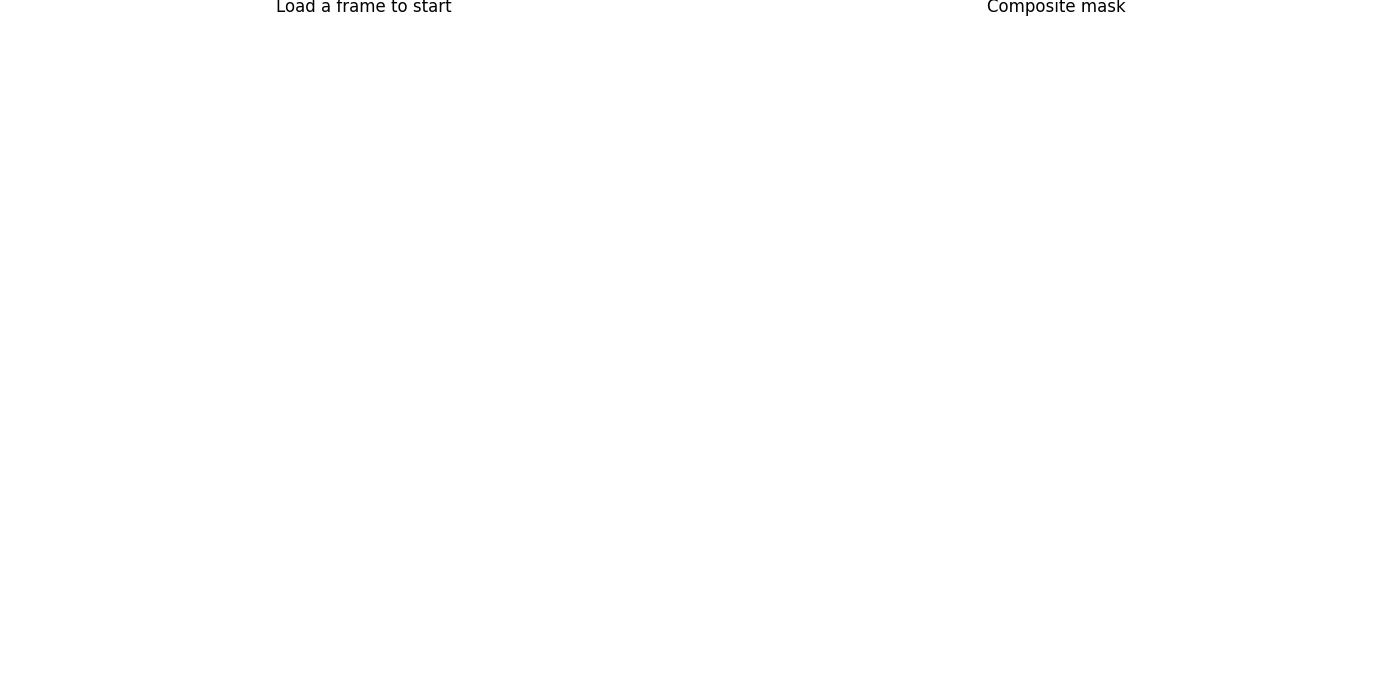

: 

In [ ]:
if 'annotator' in globals() and annotator is not None:
    try:
        annotator.close()
    except Exception:
        pass

annotator = InteractiveSAM2Annotator(predictor=predictor, sequence_dir=SEQUENCE_DIR)
annotator.display()
